<a href="https://colab.research.google.com/github/AKBER-HUSSAIN/DL-2026/blob/main/week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3073 - val_loss: 0.2654
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2640 - val_loss: 0.2609
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2544 - val_loss: 0.2463
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2383 - val_loss: 0.2282
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2199 - val_loss: 0.2109
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2045 - val_loss: 0.1967
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1914 - val_loss: 0.1848
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1813 - val_loss: 0.1761
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1734 - val_loss: 0.1690
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1668 - val_loss: 0.1627
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1609 - val_loss: 0.1571


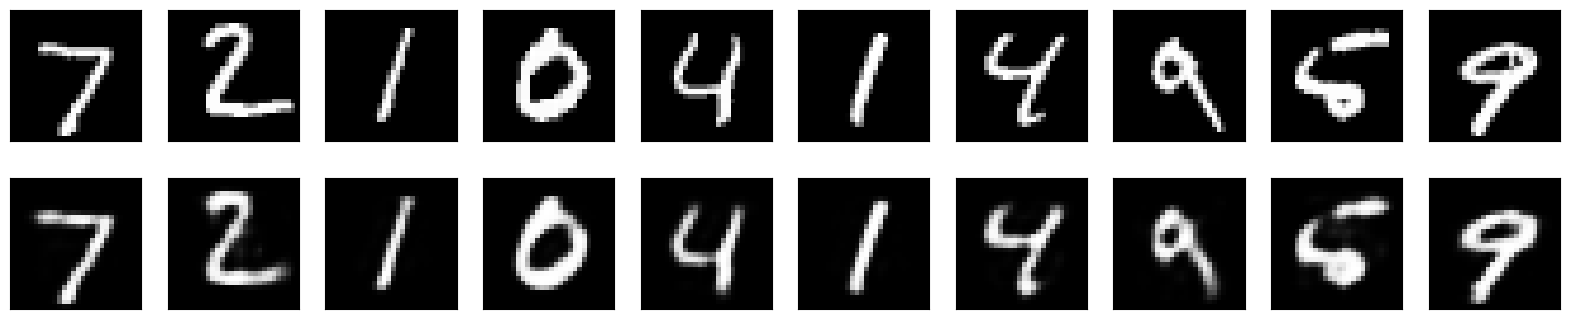

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 64  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2768 - val_loss: 0.1909
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1719 - val_loss: 0.1544
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1443 - val_loss: 0.1331
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1280 - val_loss: 0.1206
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1174 - val_loss: 0.1119
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1102 - val_loss: 0.1061
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1052 - val_loss: 0.1021
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1016 - val_loss: 0.0990
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0990 - val_loss: 0.0967
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0973 - val_loss: 0.0953
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0961 - val_loss: 0.0944
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

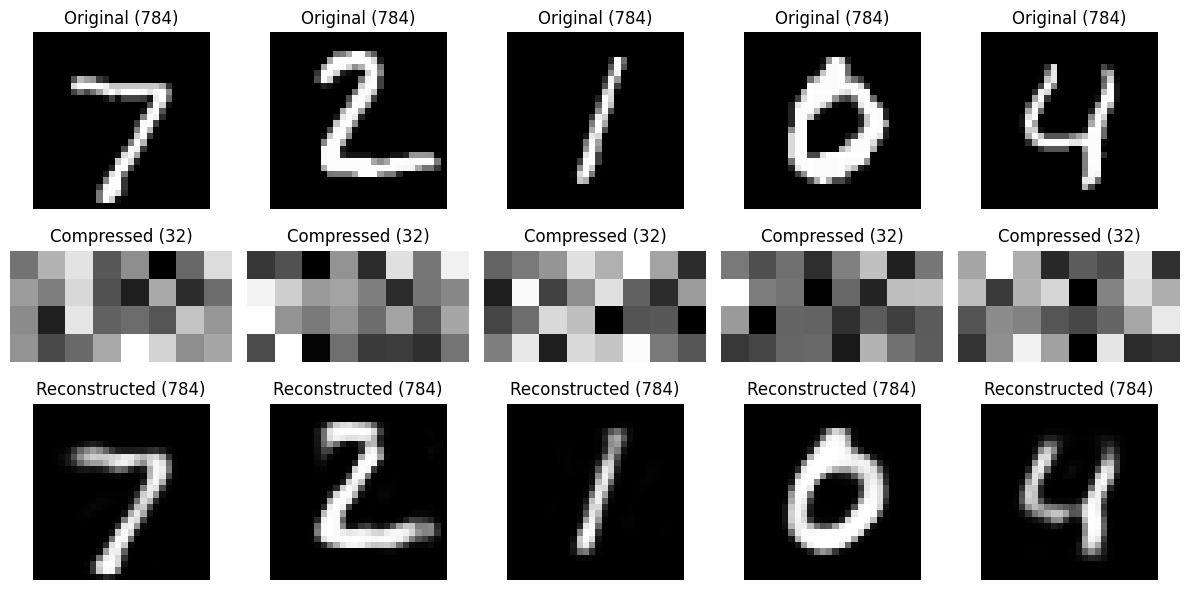

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# -----------------------------
# 1. Load and Prepare Data
# -----------------------------
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten 28x28 → 784
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# -----------------------------
# 2. Define Parameters
# -----------------------------
input_dim = 784
encoding_dim = 32  # compression

# -----------------------------
# 3. Encoder
# -----------------------------
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# -----------------------------
# 4. Decoder
# -----------------------------
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# -----------------------------
# 5. Models
# -----------------------------
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

# -----------------------------
# 6. Compile
# -----------------------------
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# -----------------------------
# 7. Train
# -----------------------------
autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# -----------------------------
# 8. Predict
# -----------------------------
encoded_imgs = encoder.predict(x_test)        # 784 → 32
decoded_imgs = autoencoder.predict(x_test)    # 32 → 784

# -----------------------------
# 9. Visualization
# -----------------------------
n = 5
plt.figure(figsize=(12, 6))

for i in range(n):
    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original (784)")
    plt.gray()
    ax.axis('off')

    # Encoded (32 → 4x8)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(4, 8))
    plt.title("Compressed (32)")   # ✅ fixed label
    plt.gray()
    ax.axis('off')

    # Reconstructed Image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Reconstructed (784)")
    plt.gray()
    ax.axis('off')

plt.tight_layout()   # ✅ better spacing
plt.show()


Training Autoencoder with dimension = 1024
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


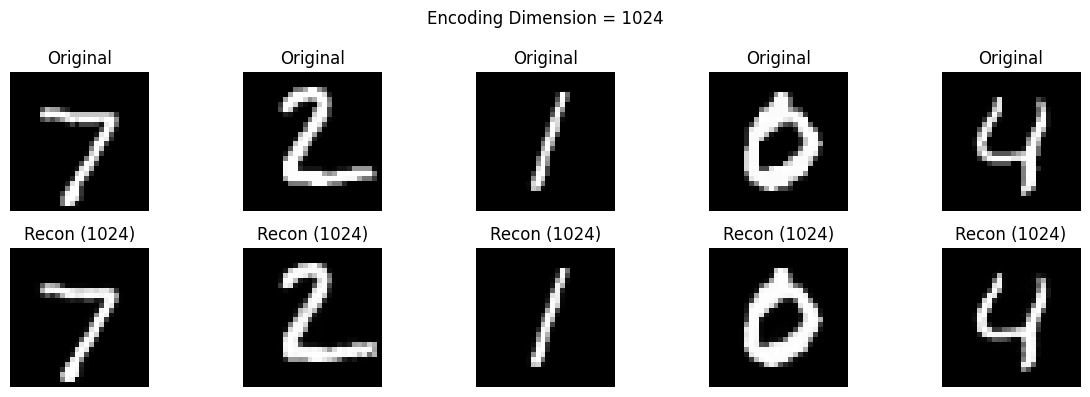


Training Autoencoder with dimension = 900
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


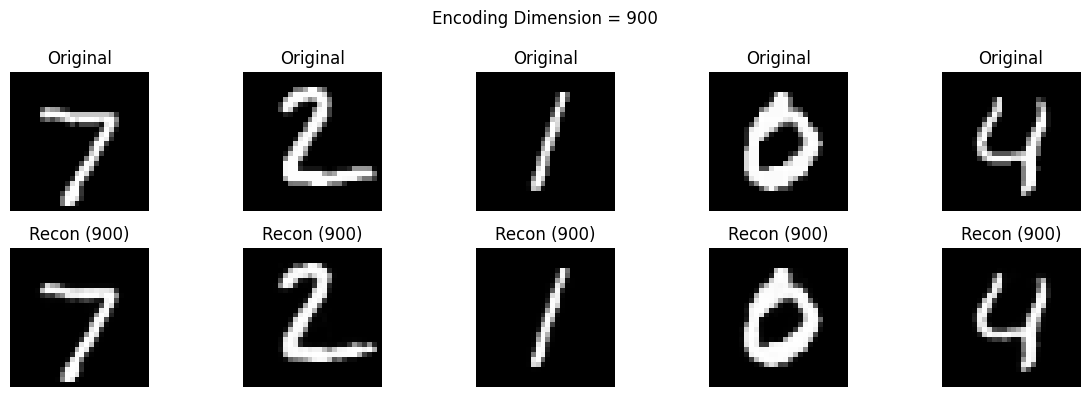


Training Autoencoder with dimension = 64
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


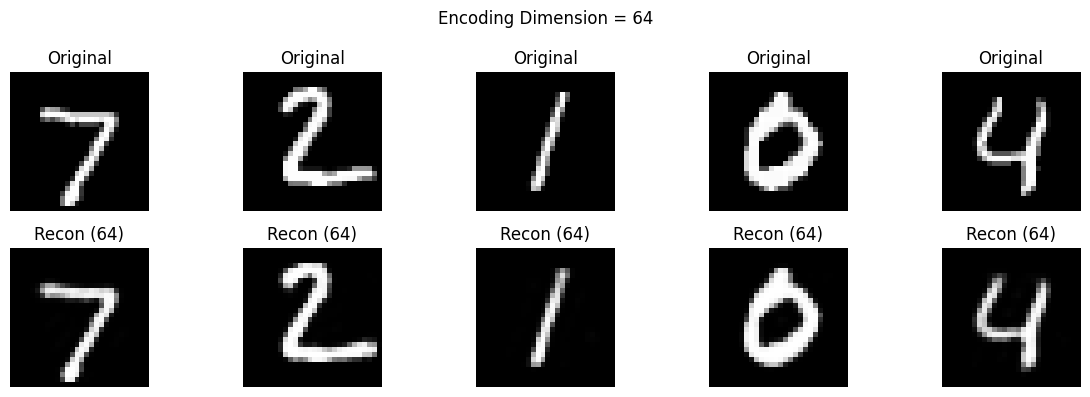


Training Autoencoder with dimension = 32
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


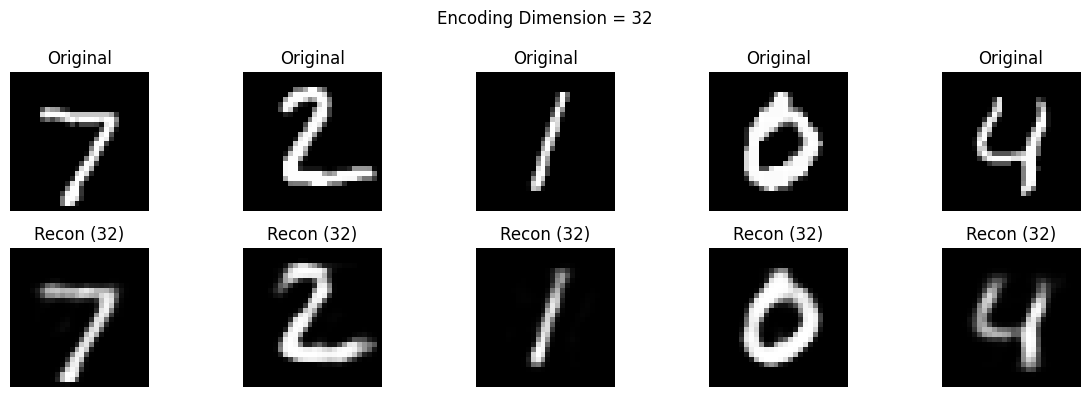


Training Autoencoder with dimension = 16
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


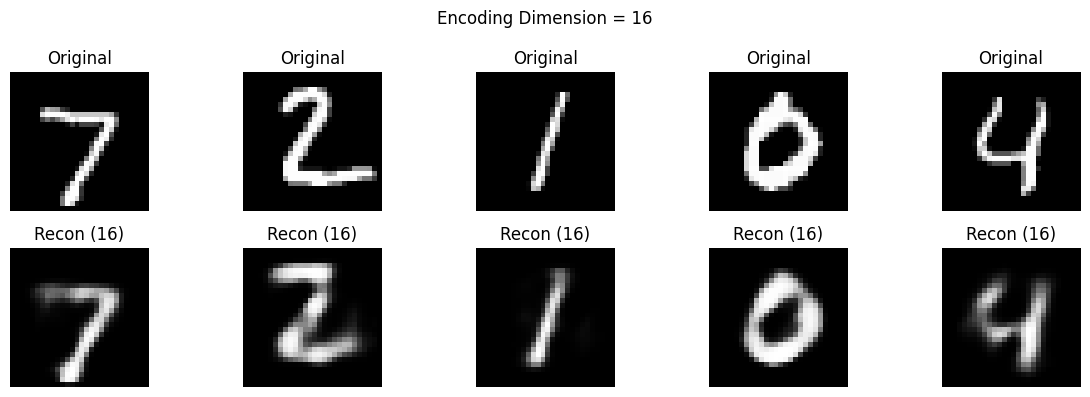


Training Autoencoder with dimension = 8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


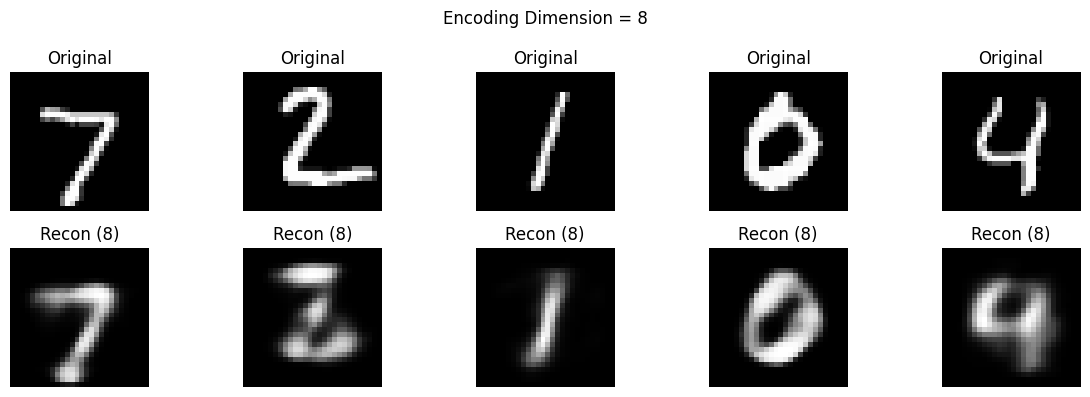


Training Autoencoder with dimension = 4
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


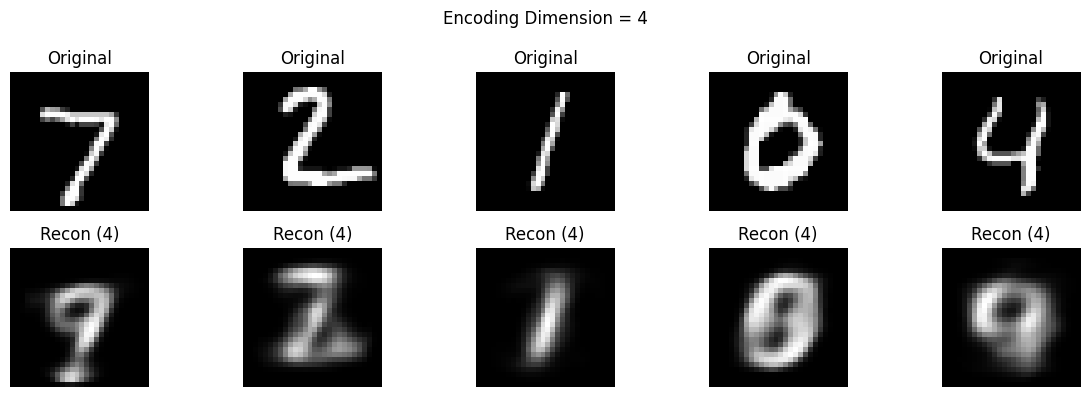


Training Autoencoder with dimension = 2
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


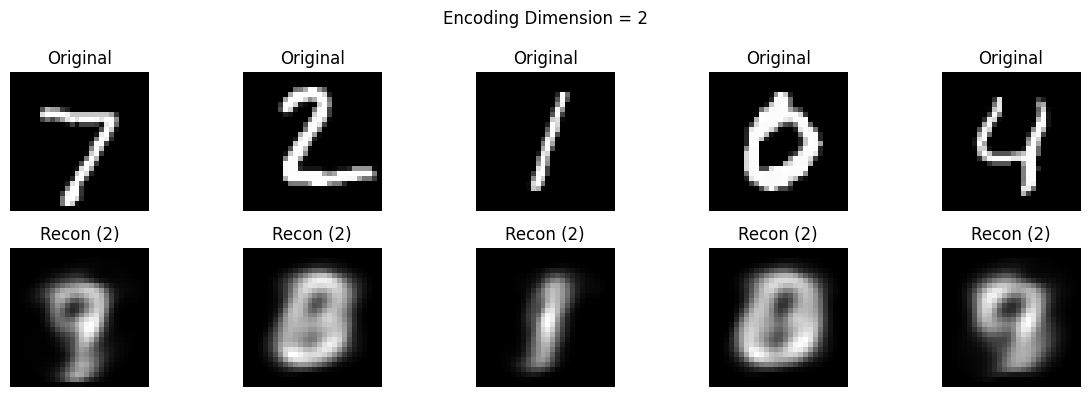


Training Autoencoder with dimension = 1
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


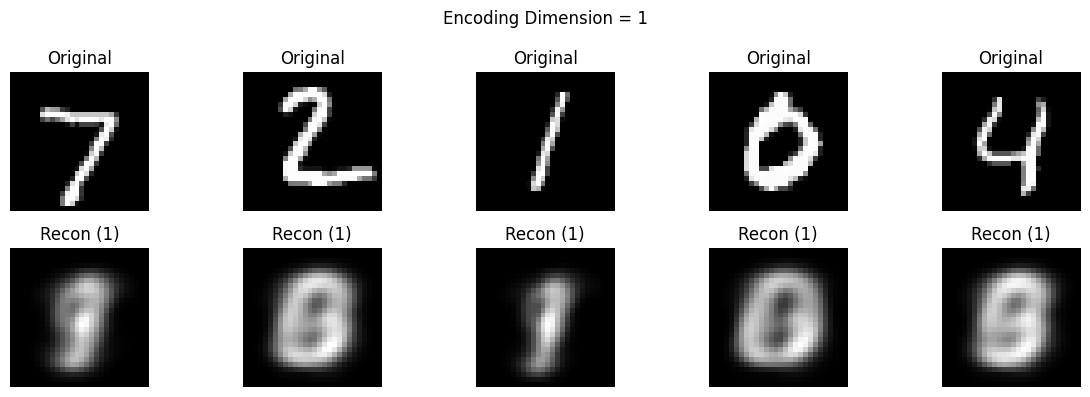

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# -----------------------------
# 1. Load Data
# -----------------------------
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# -----------------------------
# 2. Dimensions to Test
# -----------------------------
dimensions = [1024,900,64, 32, 16, 8, 4, 2, 1]

# -----------------------------
# 3. Loop Through Each Dimension
# -----------------------------
n = 5  # number of images

for encoding_dim in dimensions:
    print(f"\nTraining Autoencoder with dimension = {encoding_dim}")

    # Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)

    # Decoder
    decoded = Dense(784, activation='sigmoid')(encoded)

    # Models
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)

    # Compile
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    # Train (keep epochs small for speed)
    autoencoder.fit(x_train, x_train,
                    epochs=10,
                    batch_size=32,
                    shuffle=True,
                    validation_data=(x_test, x_test),
                    verbose=0)

    # Predict
    encoded_imgs = encoder.predict(x_test)
    decoded_imgs = autoencoder.predict(x_test)

    # -----------------------------
    # 4. Visualization
    # -----------------------------
    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Encoding Dimension = {encoding_dim}")

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28))
        plt.title("Original")
        plt.gray()
        ax.axis('off')

        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.title(f"Recon ({encoding_dim})")
        plt.gray()
        ax.axis('off')

    plt.tight_layout()
    plt.show()


Training Autoencoder with dimension = 64
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


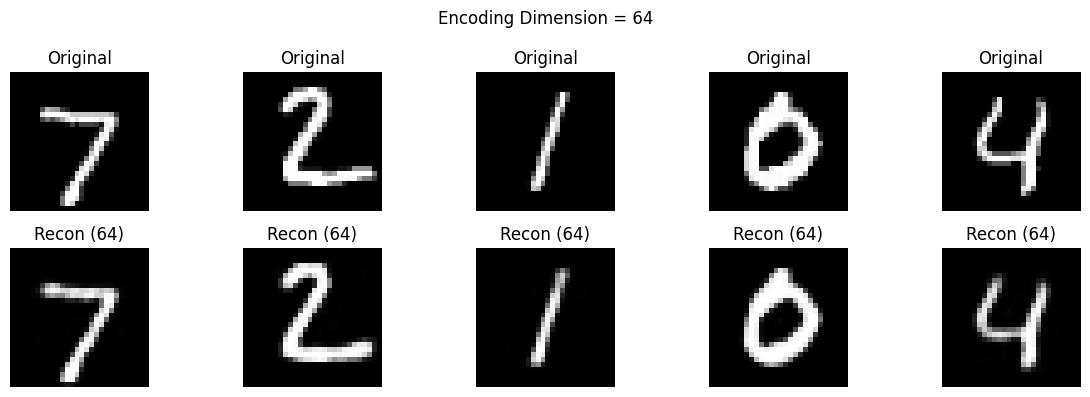


Training Autoencoder with dimension = 32
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


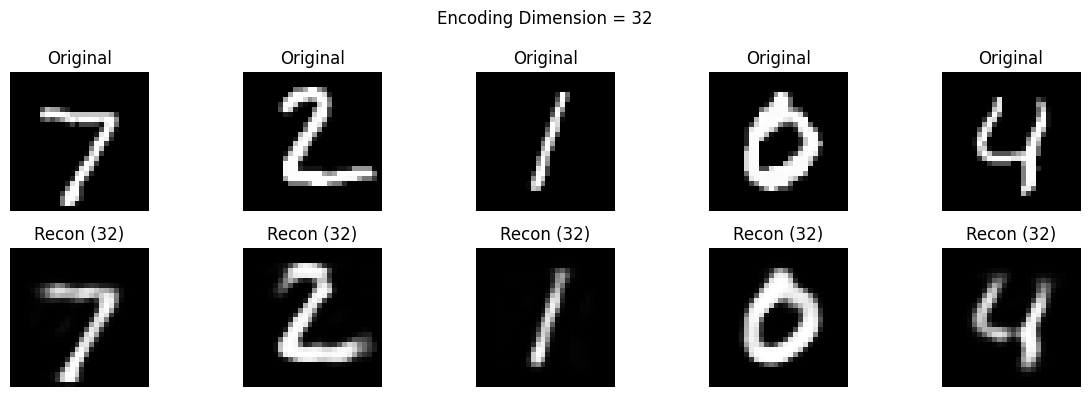


Training Autoencoder with dimension = 16
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


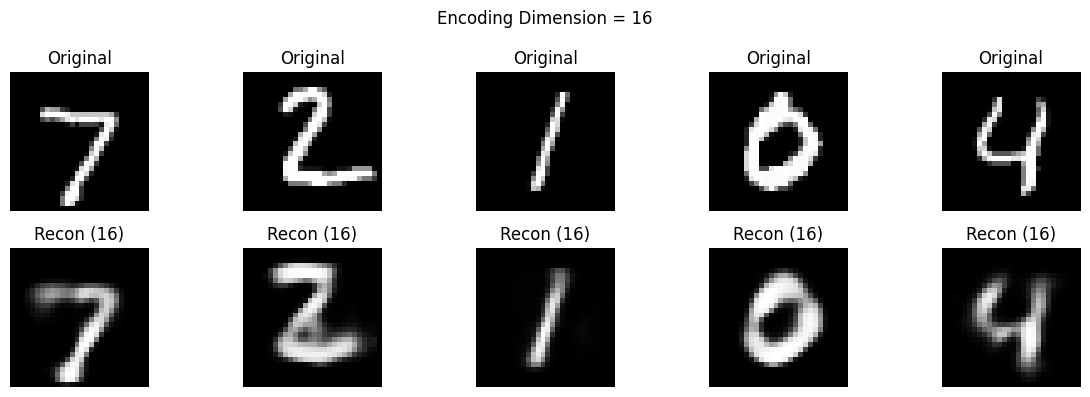


Training Autoencoder with dimension = 8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


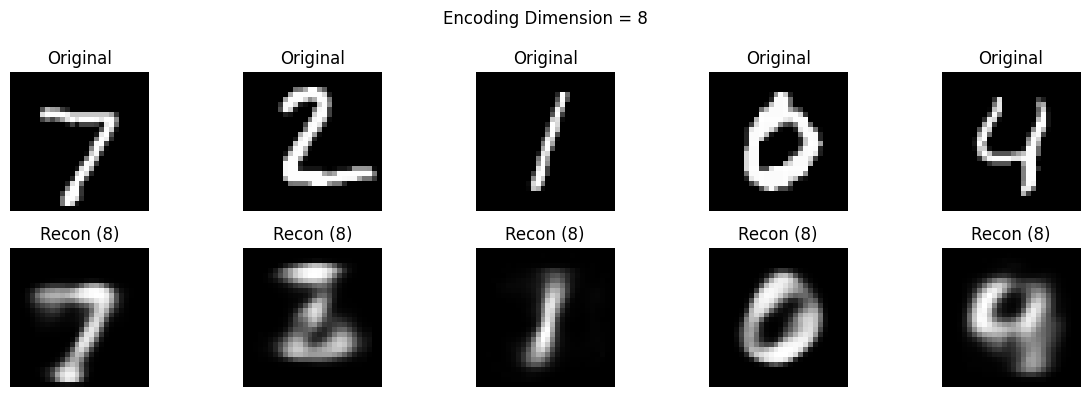


Training Autoencoder with dimension = 4
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


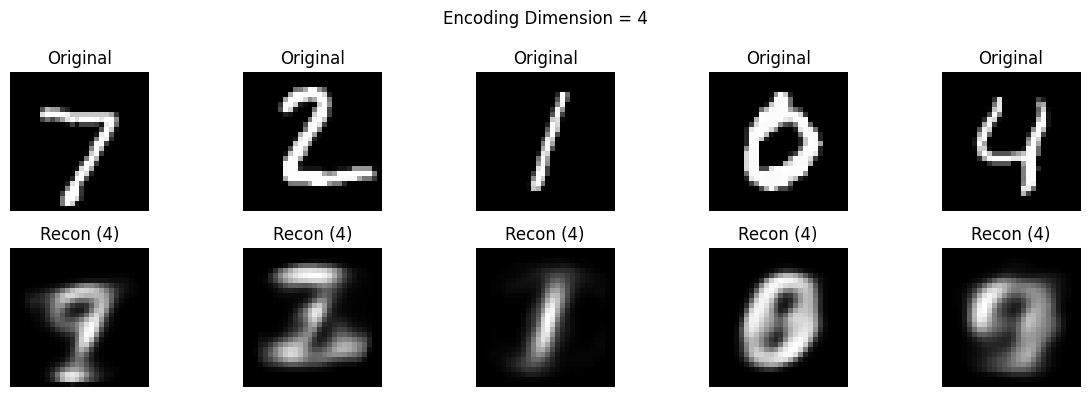


Training Autoencoder with dimension = 2
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


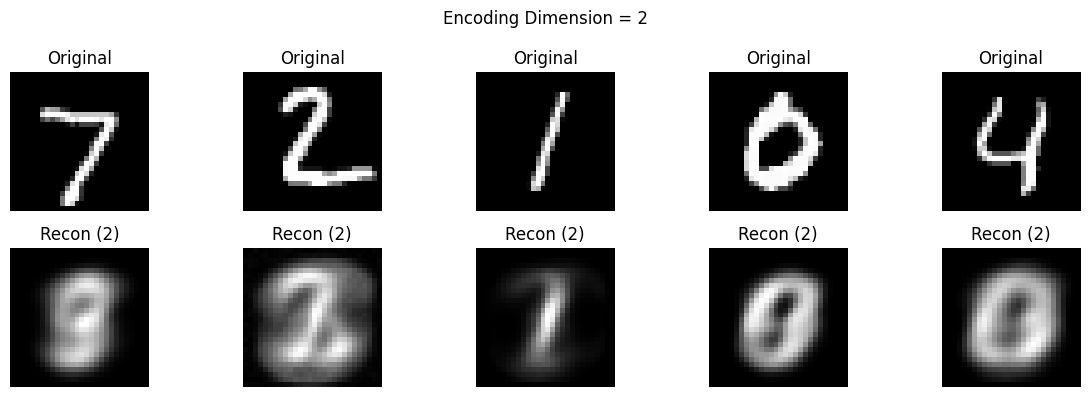


Training Autoencoder with dimension = 1
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


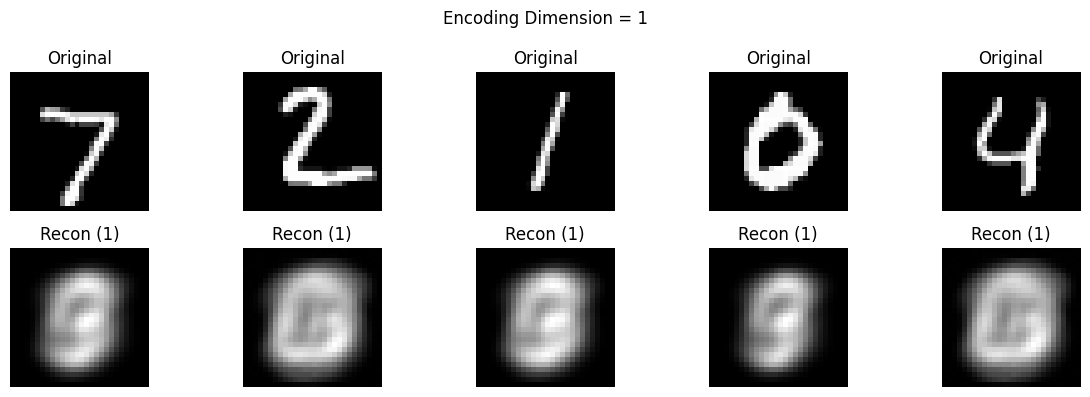

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# -----------------------------
# 1. Load Data
# -----------------------------
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# -----------------------------
# 2. Dimensions to Test
# -----------------------------
dimensions = [64, 32, 16, 8, 4, 2, 1]

# -----------------------------
# 3. Loop Through Each Dimension
# -----------------------------
n = 5  # number of images

for encoding_dim in dimensions:
    print(f"\nTraining Autoencoder with dimension = {encoding_dim}")

    # Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)

    # Decoder
    decoded = Dense(784, activation='sigmoid')(encoded)

    # Models
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)

    # Compile
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    # Train (keep epochs small for speed)
    autoencoder.fit(x_train, x_train,
                    epochs=30,
                    batch_size=512,
                    shuffle=True,
                    validation_data=(x_test, x_test),
                    verbose=0)

    # Predict
    encoded_imgs = encoder.predict(x_test)
    decoded_imgs = autoencoder.predict(x_test)

    # -----------------------------
    # 4. Visualization
    # -----------------------------
    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Encoding Dimension = {encoding_dim}")

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28))
        plt.title("Original")
        plt.gray()
        ax.axis('off')

        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.title(f"Recon ({encoding_dim})")
        plt.gray()
        ax.axis('off')

    plt.tight_layout()
    plt.show()


Training Autoencoder with dimension = 64
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


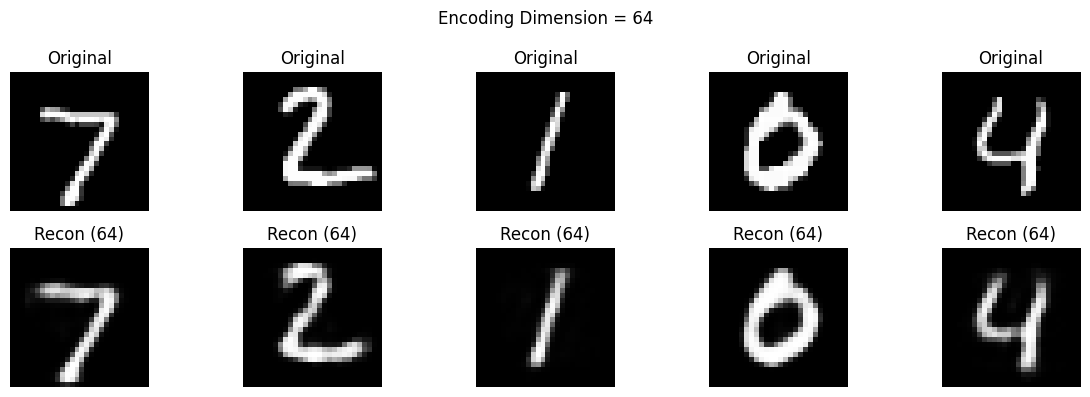


Training Autoencoder with dimension = 32
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


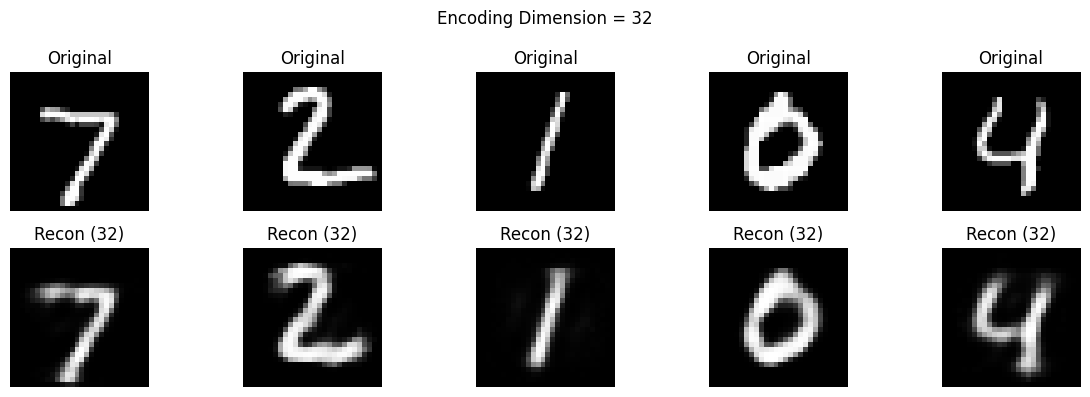


Training Autoencoder with dimension = 16
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


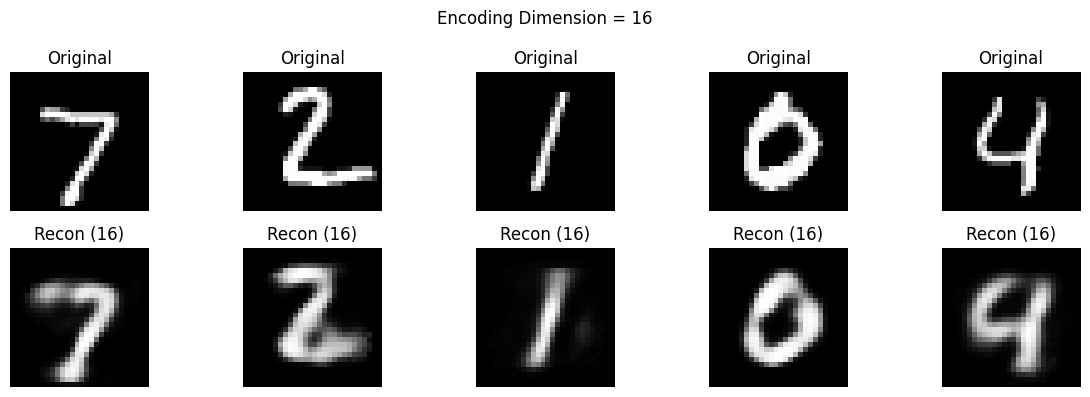


Training Autoencoder with dimension = 8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


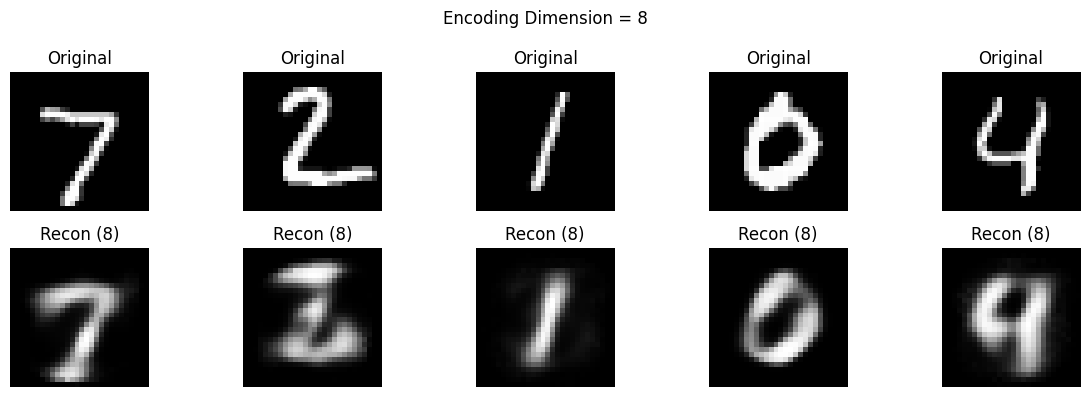


Training Autoencoder with dimension = 4
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


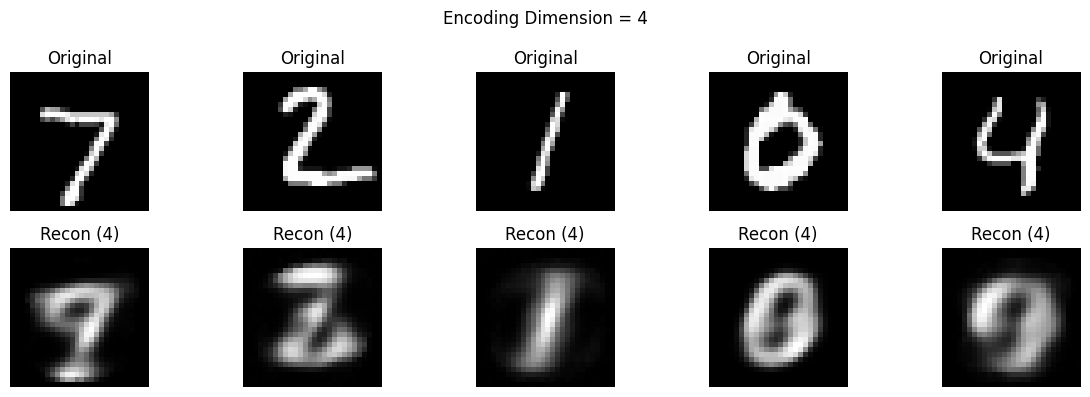


Training Autoencoder with dimension = 2
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


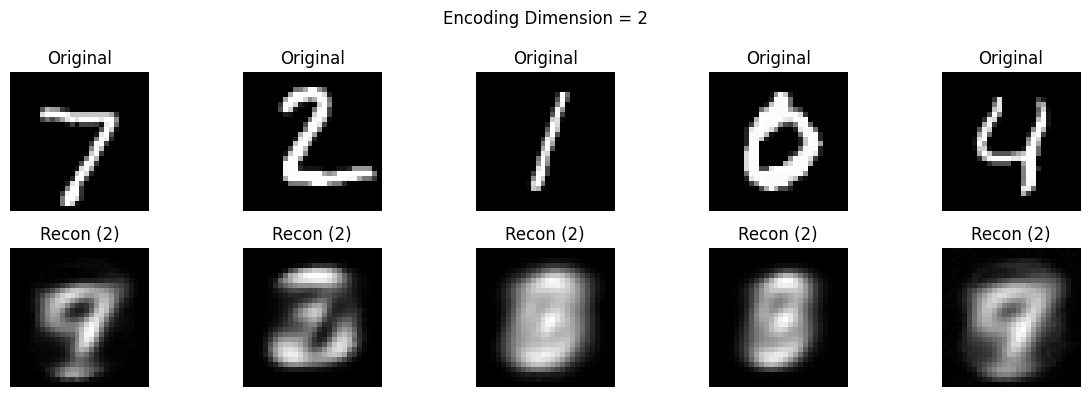


Training Autoencoder with dimension = 1
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


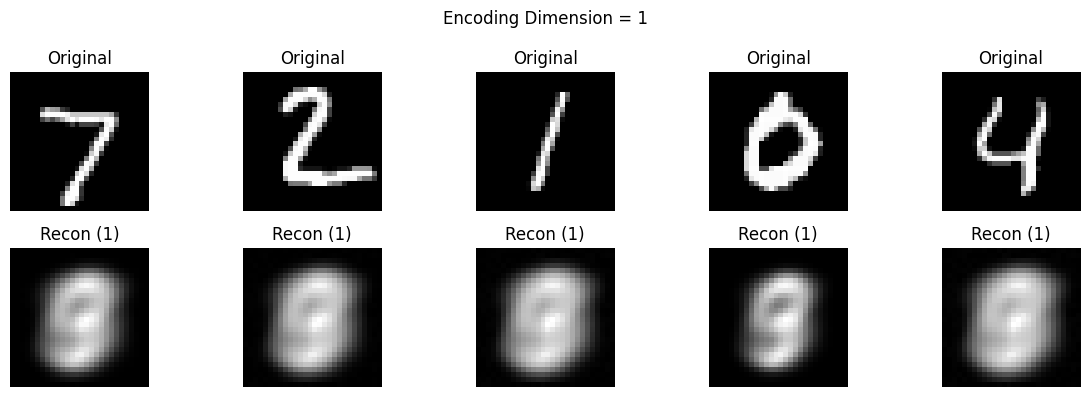

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# -----------------------------
# 1. Load Data
# -----------------------------
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# -----------------------------
# 2. Dimensions to Test
# -----------------------------
dimensions = [64, 32, 16, 8, 4, 2, 1]

# -----------------------------
# 3. Loop Through Each Dimension
# -----------------------------
n = 5  # number of images

for encoding_dim in dimensions:
    print(f"\nTraining Autoencoder with dimension = {encoding_dim}")

    # Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)

    # Decoder
    decoded = Dense(784, activation='sigmoid')(encoded)

    # Models
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)

    # Compile
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    # Train (keep epochs small for speed)
    autoencoder.fit(x_train, x_train,
                    epochs=10,
                    batch_size=512,
                    shuffle=True,
                    validation_data=(x_test, x_test),
                    verbose=0)

    # Predict
    encoded_imgs = encoder.predict(x_test)
    decoded_imgs = autoencoder.predict(x_test)

    # -----------------------------
    # 4. Visualization
    # -----------------------------
    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Encoding Dimension = {encoding_dim}")

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28))
        plt.title("Original")
        plt.gray()
        ax.axis('off')

        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.title(f"Recon ({encoding_dim})")
        plt.gray()
        ax.axis('off')

    plt.tight_layout()
    plt.show()